# Influence of `D` (NGS sequencing depth) on signal fidelity and viability-step recovery, at fixed `mu=50`, `T_viab=0.8`, `noise_viab=0.5`

`D` is the total sequencing depth at each of the 3 NGS checkpoints (`lambda0p`, `lambda2p`,
`lambda3p`): with `multinomialNGS=True` (this project's standing default), reads are drawn as
`Multinomial(D, proportions)` in `sequence_reads` (`sequence_classesV1.py`) -- reads sum to
exactly `D`, spread over the pool according to its true proportions. Small `D` means each
sequence's read count is a noisy, low-precision estimate of its true proportion (more
"pipetting/sequencing" sampling noise on top of everything else); large `D` means read counts
converge toward the true proportions almost exactly.

`mu = rho * N1 / d0` fixed at `50`, `T_viab` fixed at `0.8` and `noise_viab` fixed at `0.5` --
the same combination `noise_viab_sweep.ipynb` used, including the same `d0=200,000` pool -- so
this sweep is directly comparable to that one, this time varying `D` instead of `noise_viab`.

**Question.** As `D` grows, how do (a) the Pearson correlation between the true noiseless
viability score and the NGS-measured `target1`, and (b) the top-1000 recovery between the three
pairwise views (GT, protocol-measured `target1`, MLP-predicted `target1`) on a held-out test
fold, respond? Same `ProfileMLP` / train-test-split / `topk_recovery` convention as the sibling
notebooks in this folder.

## 0. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as the sibling notebooks.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from flax import nnx
import optax

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import load_F_viab_aav9_mlp, load_J_viab_aav9_mlp, NUM_AMINO_ACIDS, NUM_POSITIONS

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Ground truth and fixed pool

Identical real AAV9 `F_viab`/`J_viab` and permuted `F_sel`/`J_sel` as the sibling notebooks
(`F_sel`/`J_sel` are constructed but never used below -- only the viability channel, `target1`,
is swept here). `d0=200,000`, same as `noise_viab_sweep.ipynb`.

In [3]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

key_F, key_J = jax.random.split(jax.random.key(0), 2)
sigma_F = jax.random.permutation(key_F, NUM_AMINO_ACIDS)
F_sel   = F_viab[sigma_F, :]
sigma_J = jax.random.permutation(key_J, NUM_AMINO_ACIDS)
J_sel   = J_viab[:, :, sigma_J, :][:, :, :, sigma_J]

key_pool = jax.random.key(1)
N = 200_000
sequences = jax.random.randint(key_pool, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)
d0 = N

print(f"F_viab shape: {F_viab.shape}   J_viab shape: {J_viab.shape}   sequences: {N:,}")

F_viab shape: (20, 7)   J_viab shape: (7, 7, 20, 20)   sequences: 200,000


## 2. Fixed 50,000-sequence evaluation pool (SAME key in every notebook)

A separate, FIXED `50,000`-sequence pool, generated once with a hardcoded key
(`EVAL_POOL_KEY_SEED=999`, `EVAL_POOL_SIZE=50_000` -- the exact same pair of values used in
`deeper_mlp/diversity_sweep_deeper_mlp.ipynb` and every other notebook that wants directly
comparable top-K recovery numbers), held out from training entirely. Every model trained at
every `D` gets evaluated on this SAME `50,000` sequences (in addition to this
notebook's own in-sweep test fold), so top-1000 recovery becomes comparable both across
`D` within this notebook AND across every other sweep notebook using the same fixed
key -- independent of this notebook's own pool size or train/test split.

In [ ]:
EVAL_POOL_KEY_SEED = 999   # fixed across every notebook -- reuse this exact value for comparable numbers
EVAL_POOL_SIZE     = 50_000

def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Noiseless ground-truth score, decoupled from any Protocol instance -- same formula as
    Protocol.compute_score, applied directly to an arbitrary sequence array."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores

eval_sequences = jax.random.randint(jax.random.key(EVAL_POOL_KEY_SEED),
                                     shape=(EVAL_POOL_SIZE, NUM_POSITIONS),
                                     minval=0, maxval=NUM_AMINO_ACIDS)
eval_viab_score = np.asarray(compute_score_array(eval_sequences, F_viab, J_viab))
X_eval = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(eval_sequences)].reshape(EVAL_POOL_SIZE, -1)

print(f"fixed evaluation pool: {EVAL_POOL_SIZE:,} sequences (key seed={EVAL_POOL_KEY_SEED})")
print(f"GT score range on eval pool: [{eval_viab_score.min():.2f}, {eval_viab_score.max():.2f}]")

## 3. Fixed `mu=50`, `T_viab=0.8`, `noise_viab=0.5`, `D` grid, and train/test split

`rho=RHO_REF`, `N1` solved so `rho * N1 / d0 == 50` exactly (same regime as
`noise_viab_sweep.ipynb`, `N1` comes out to `1e10`, above `N0`, already validated there).
`D_GRID` spans four orders of magnitude around the project's usual baseline `D=1e9`.

In [4]:
RHO_REF          = 1e-3
MU_FIXED         = 50
N1_FIXED         = MU_FIXED * d0 / RHO_REF
T_VIAB_FIXED     = 0.8
NOISE_VIAB_FIXED = 0.5

D_GRID = [1e6, 3e6, 1e7, 3e7, 1e8, 3e8, 1e9, 3e9, 1e10]
eps = 1.0

protocol = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=N1_FIXED,
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_FIXED, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_FIXED,
        )
protocol._rho = float(RHO_REF)
viab_score = np.array(protocol.compute_score(F_viab, J_viab))
original_D = protocol.D

print(f"mu = {protocol._rho * protocol.N1 / d0:.2f}   T_viab = {protocol._T_viab}   "
      f"noise_viab = {protocol.noise_viab}")
print(f"D grid: {D_GRID}")

mu = 50.00   T_viab = 0.8   noise_viab = 0.5
D grid: [1000000.0, 3000000.0, 10000000.0, 30000000.0, 100000000.0, 300000000.0, 1000000000.0, 3000000000.0, 10000000000.0]


In [5]:
K_TOPK = 1000

X_all = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences)].reshape(N, -1)
idx_train, idx_test = train_test_split(np.arange(N), test_size=0.5, random_state=0)
X_train_full, X_test = X_all[idx_train], X_all[idx_test]
viab_score_test = viab_score[idx_test]
k_frac_test = K_TOPK / len(idx_test)

print(f"pool: {N:,}   train: {len(idx_train):,}   test: {len(idx_test):,}   "
      f"top-{K_TOPK} = top-{100 * k_frac_test:.2f}% of the test set")

pool: 200,000   train: 100,000   test: 100,000   top-1000 = top-1.00% of the test set


## 4. Simulate the SAME experimental configuration on the fixed eval pool

To get a genuine `GT<->protocol` recovery number on the fixed `50,000`-sequence eval pool
(section 2), build a SEPARATE `ProtocolV3` object dedicated to it alone -- NOT mixed into the
training pool (that would dilute `D`/`d0` and distort `mu`). `N1` is recomputed for the eval
pool's own `d0=50,000` to keep the same `mu`. Same reused-object / advancing-PRNG-key convention
as `protocol` itself: `protocol_eval.D` gets mutated to match every sweep point, right
alongside `protocol.D`, in section 6's loop.

In [ ]:
N1_eval = MU_FIXED * EVAL_POOL_SIZE / RHO_REF

protocol_eval = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=N1_eval,
        dilution_factor=10, sequences=eval_sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )
protocol_eval._rho = float(RHO_REF)

print(f"mu (eval pool) = {protocol_eval._rho * protocol_eval.N1 / EVAL_POOL_SIZE:.2f}")

## 5. `ProfileMLP`: same architecture as the sibling notebooks

Identical `ProfileMLP` and warmup-cosine-decay AdamW / early-stopping training loop as
`noise_viab_sweep.ipynb`, including `batch_size=2048` (the train fold is `100,000` sequences,
10x the smaller-pool sibling notebooks -- `2048` keeps steps-per-epoch comparable).

In [6]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Identical to the sibling notebooks' ProfileMLP
    (Linear + BatchNorm + Dropout + gelu).
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x, train: bool, rngs: nnx.Rngs = None):
        x = self.linear1(x)
        self.batchnorm1.use_running_average = not train
        x = self.batchnorm1(x)
        x = nnx.gelu(x)
        x = self.dropout1(x, rngs=rngs) if train else x
        x = self.linear2(x)
        self.batchnorm2.use_running_average = not train
        x = self.batchnorm2(x)
        x = nnx.gelu(x)
        x = self.dropout2(x, rngs=rngs) if train else x
        x = self.linear3(x)
        return x[:, 0]

In [7]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=2048,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0

    for epoch in range(epochs):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm = jax.random.permutation(perm_key, n_train)
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, n_train - n_train % batch_size, batch_size):
            xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            train_step(model, optimizer, xb, yb, rngs)

        val_loss = float(eval_step(model, X_val, y_val))
        if val_loss < best_val - 1e-6:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"  early stop at epoch {epoch}, best val MSE = {best_val:.4f}")
                break

    if best_state is not None:
        nnx.update(model, best_state)
    return model, best_val

## 6. Sweep: one fresh `loop_DE()` + one fresh `ProfileMLP` per `D`

For each `D`: mutate `protocol.D` in place (same reused `protocol` object / advancing-PRNG-key
convention as the other sweeps in this folder), reset `lambda0`, run one `loop_DE()` round to
get `target1`, train a fresh `ProfileMLP` on the train fold, then compare on the held-out test
fold: Pearson `r` and top-`K_TOPK` recovery, each across the three pairwise views (GT, protocol,
MLP). `protocol.D` is restored to its original value afterward.

In [8]:
records = []

try:
    for D_val in tqdm(D_GRID, desc="D sweep"):
        protocol.D = float(D_val)
        protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
        protocol_eval.D = float(D_val)
        protocol_eval.lambda0 = jnp.full(protocol_eval.d0, protocol_eval.N0 / protocol_eval.d0)

        _bio_row, ngs_row = protocol.loop_DE()
        lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
        target1 = np.log((lambda2p + eps) / (lambda0p + eps))
        _bio_row_eval, ngs_row_eval = protocol_eval.loop_DE()
        lambda0p_eval, lambda2p_eval, _lambda3p_eval = (np.asarray(a) for a in ngs_row_eval)
        target1_eval = np.log((lambda2p_eval + eps) / (lambda0p_eval + eps))
        target1_train, target1_test = target1[idx_train], target1[idx_test]

        Xtr, ytr, Xva, yva = split_train_val(X_train_full, target1_train, val_frac=0.15, seed=0)
        model, val_mse = train_profile_mlp(Xtr, ytr, Xva, yva, epochs=300, patience=20, verbose=False)
        pred_test = np.asarray(predict_log_enrichment(model, jnp.asarray(X_test)))
        pred_eval = np.asarray(predict_log_enrichment(model, jnp.asarray(X_eval)))

        records.append(dict(
            D=D_val,
            r_gt_protocol=pearson(viab_score_test, target1_test),
            r_gt_mlp=pearson(viab_score_test, pred_test),
            r_protocol_mlp=pearson(target1_test, pred_test),
            rec_gt_protocol=topk_recovery(viab_score_test, target1_test, k=K_TOPK),
            rec_gt_mlp=topk_recovery(viab_score_test, pred_test, k=K_TOPK),
            rec_protocol_mlp=topk_recovery(target1_test, pred_test, k=K_TOPK),
            rec_gt_mlp_eval=topk_recovery(eval_viab_score, pred_eval, k=K_TOPK),
            r_gt_protocol_eval=pearson(eval_viab_score, target1_eval),
            rec_gt_protocol_eval=topk_recovery(eval_viab_score, target1_eval, k=K_TOPK),
            r_protocol_mlp_eval=pearson(target1_eval, pred_eval),
            rec_protocol_mlp_eval=topk_recovery(target1_eval, pred_eval, k=K_TOPK),
        ))
finally:
    protocol.D = original_D
    protocol_eval.D = original_D

D_sweep_df = pd.DataFrame(records)
D_sweep_df

D sweep: 100%|██████████| 9/9 [12:02<00:00, 80.22s/it]


,D,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp
0,1.000000e+06,0.661507,0.727873,0.884493,0.744,0.764,0.656
1,3.000000e+06,0.761724,0.787701,0.954858,0.831,0.791,0.732
2,1.000000e+07,0.832484,0.844836,0.976952,0.875,0.810,0.773
3,3.000000e+07,0.878074,0.884992,0.983761,0.900,0.784,0.769
4,1.000000e+08,0.917071,0.921182,0.988143,0.907,0.794,0.773
5,3.000000e+08,0.944415,0.947350,0.990581,0.901,0.799,0.778
6,1.000000e+09,0.965942,0.967421,0.992038,0.908,0.799,0.779
7,3.000000e+09,0.979489,0.980601,0.993260,0.910,0.795,0.779
8,1.000000e+10,0.988926,0.989545,0.994394,0.913,0.780,0.772


## 7. Pearson correlation vs `D`

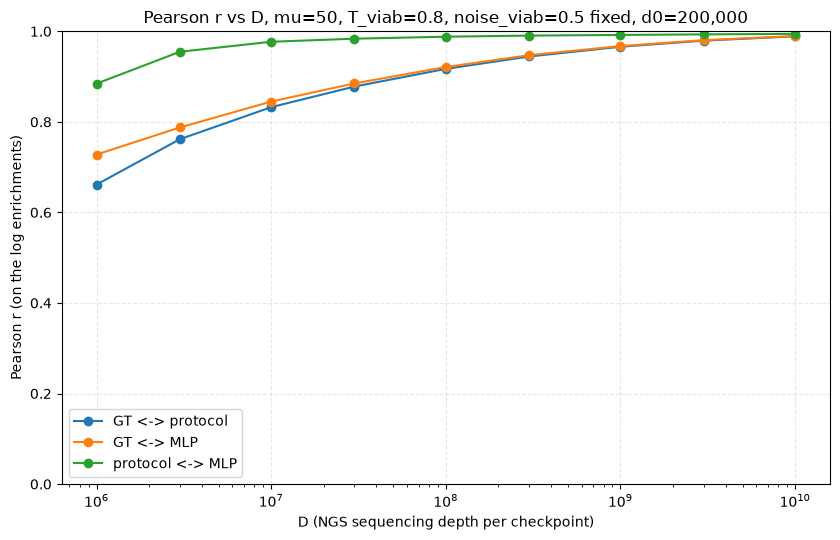

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(D_sweep_df["D"], D_sweep_df["r_gt_protocol"],  "o-", label="GT <-> protocol")
ax.plot(D_sweep_df["D"], D_sweep_df["r_gt_mlp"],       "o-", label="GT <-> MLP")
ax.plot(D_sweep_df["D"], D_sweep_df["r_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.set_xlabel("D (NGS sequencing depth per checkpoint)")
ax.set_ylabel("Pearson r (on the log enrichments)")
ax.set_title(f"Pearson r vs D, mu={MU_FIXED}, T_viab={T_VIAB_FIXED}, noise_viab={NOISE_VIAB_FIXED} fixed, d0={d0:,}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Top-1000 recovery vs `D` (in-sweep test fold)

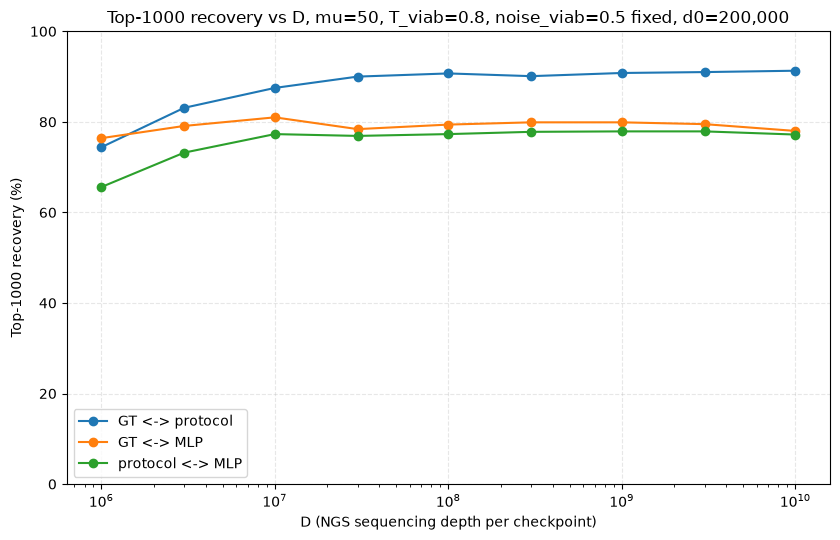

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(D_sweep_df["D"], 100 * D_sweep_df["rec_gt_protocol"],  "o-", label="GT <-> protocol")
ax.plot(D_sweep_df["D"], 100 * D_sweep_df["rec_gt_mlp"],       "o-", label="GT <-> MLP")
ax.plot(D_sweep_df["D"], 100 * D_sweep_df["rec_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.set_xlabel("D (NGS sequencing depth per checkpoint)")
ax.set_ylabel(f"Top-{K_TOPK} recovery (%)")
ax.set_title(f"Top-{K_TOPK} recovery vs D, mu={MU_FIXED}, T_viab={T_VIAB_FIXED}, noise_viab={NOISE_VIAB_FIXED} fixed, d0={d0:,}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## 9. Top-1000 recovery on the FIXED 50,000-sequence eval pool vs `D`

Same `50,000` sequences (section 2) at every `D` -- comparable across the whole
grid AND across every other notebook using the same `EVAL_POOL_KEY_SEED=999`/`EVAL_POOL_SIZE=50_000`
pair (e.g. `deeper_mlp/diversity_sweep_deeper_mlp.ipynb`). `GT<->protocol` (gray) comes from section 4's dedicated `protocol_eval` simulation,
mutated to the same `D` as `protocol` at every sweep point (section 6) -- the
natural reference for whether the MLP actually beats the raw protocol measurement on
this common benchmark.

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(D_sweep_df["D"], 100 * D_sweep_df["rec_gt_protocol_eval"], "o-", color="gray", label="GT <-> protocol (fixed eval pool)")
ax.plot(D_sweep_df["D"], 100 * D_sweep_df["rec_gt_mlp_eval"], "o-", color="tab:red", label="GT <-> MLP (fixed eval pool)")
ax.axhline(100 * K_TOPK / EVAL_POOL_SIZE, color="black", lw=1, ls="--", label="random baseline")
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.set_xlabel("D (NGS sequencing depth per checkpoint)")
ax.set_ylabel(f"Top-{K_TOPK} recovery on the fixed {EVAL_POOL_SIZE:,}-sequence eval pool (%)")
ax.set_title("GT <-> MLP recovery on a COMMON, fixed evaluation population")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## How to read this

- Both curves should be MONOTONIC increasing in `D` (unlike the `T_viab` sweep's unimodal
  shape): more sequencing depth means less read-count sampling noise at every point in the
  library, with no analogous "too much of a good thing" failure mode -- so there's no reason to
  expect a peak-then-decline shape here.
- Expect diminishing returns at high `D`: once average reads/sequence (`D/d0`) is already large
  relative to the OTHER noise sources at play (`noise_viab`-driven expression noise, the Poisson
  capsid-count draw, `mu`-driven cell-transfection sampling), pushing `D` even higher stops
  helping much -- the curve should flatten out well before `D=1e10`, not keep climbing linearly.
- Same `GT<->MLP > protocol<->MLP` ordering expected at every `D`, and the same denoising
  question as `noise_viab_sweep.ipynb`: does `GT<->MLP` stay above `GT<->protocol` at low `D`
  (few reads, most in need of denoising), the same way it does at high `noise_viab`?
- **Section 9 (fixed eval pool)** gives the same `GT<->MLP` recovery curve on the common `50,000`-sequence population (`EVAL_POOL_KEY_SEED=999`) shared with every other sweep notebook -- use it to compare `D`'s effect directly against `noise_viab`'s (`noise_viab_sweep.ipynb`) or `d0`'s (`diversity_sweep.ipynb`) on the exact same benchmark.